In [ ]:
!pip install tdigest
import numpy as np
import matplotlib.pyplot as plt
from tdigest import TDigest
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans

## **Code Block 3.1: ROC and PRC curves using synthetic dataset**

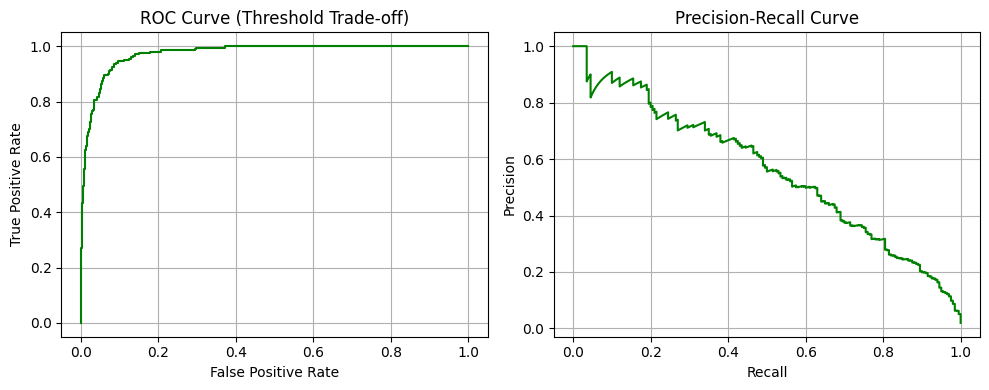

In [ ]:
np.random.seed(42)
normal = np.random.normal(0, 1, 10000)
anomalies = np.random.normal(2.5, 0.8, 200)

data = np.concatenate([normal, anomalies])
labels = np.array([0]*len(normal) + [1]*len(anomalies))

fpr, tpr, thresholds = roc_curve(labels, data)
precision, recall, pr_thresholds = precision_recall_curve(labels, data)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='green')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Threshold Trade-off)")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()

plt.tight_layout()
plt.show()

## **Code Block 3.2: Syntax to generate comparison of quantile threshold versus t-Digest**

Quantile Threshold (99.5%): 3.1123527965277313
t-Digest Threshold (99.5%): 3.112630098271927


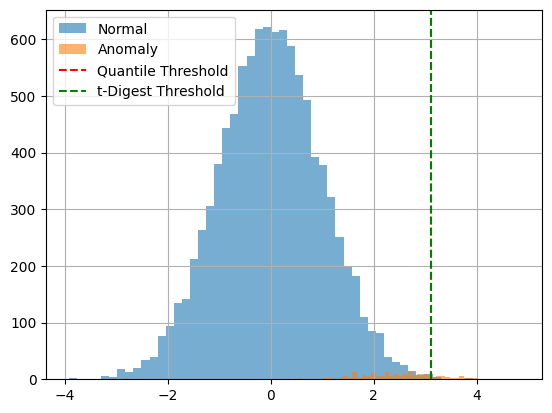

In [ ]:
percentile = 99.5
threshold = np.percentile(data, percentile)

preds = (data > threshold).astype(int)

print(f"Quantile Threshold ({percentile}%):", threshold)

td = TDigest()
# Simulate streaming
for x in data:
    td.update(x)

td_threshold = td.percentile(percentile)

print(f"t-Digest Threshold ({percentile}%):", td_threshold)

plt.figure()
plt.hist(normal, bins=50, alpha=0.6, label="Normal")
plt.hist(anomalies, bins=50, alpha=0.6, label="Anomaly")

plt.axvline(threshold, color='r', linestyle='--', label="Quantile Threshold")
plt.axvline(td_threshold, color='g', linestyle='--', label="t-Digest Threshold")

plt.legend()
# plt.title("Quantile vs t-Digest Thresholding")
plt.grid()
plt.show()

## **Code Block 3.3: Proximity-based Anomaly with k-NN using synthetic data**

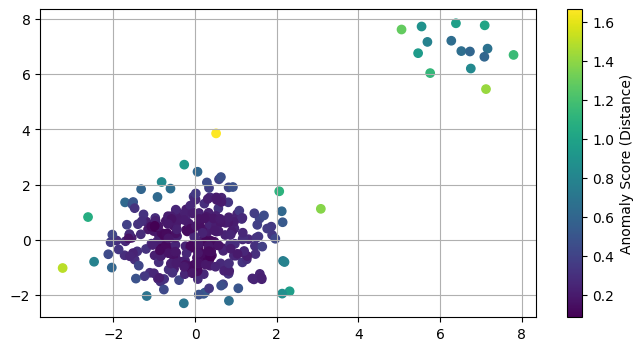

In [ ]:
np.random.seed(42)
normal = np.random.randn(300, 2)
anomalies = np.random.uniform(low=5, high=8, size=(15, 2))
X = np.vstack([normal, anomalies])

def knn_anomaly_score(X, k=5, method="kth"):
    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(X)

    distances, _ = nbrs.kneighbors(X)

    if method == "kth":
        # distance to k-th neighbor
        scores = distances[:, -1]
    elif method == "mean":
        # average distance
        scores = distances.mean(axis=1)

    return scores

# Compute scores
k = 5
scores_kth = knn_anomaly_score(X, k=k, method="kth")
scores_mean = knn_anomaly_score(X, k=k, method="mean")
plt.figure(figsize=(8,4))
plt.scatter(X[:,0], X[:,1], c=scores_kth, cmap='viridis')
plt.colorbar(label="Anomaly Score (Distance)")
plt.title("Proximity-based Anomaly Scores")
plt.grid()
plt.show()

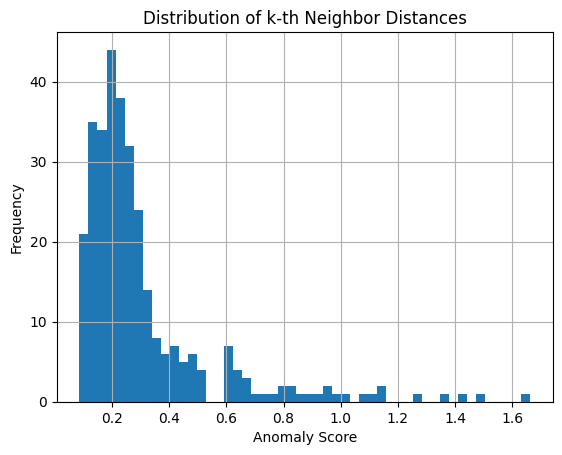

In [ ]:
plt.figure()
plt.hist(scores_kth, bins=50)
plt.title("Distribution of k-th Neighbor Distances")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.grid()
plt.show()

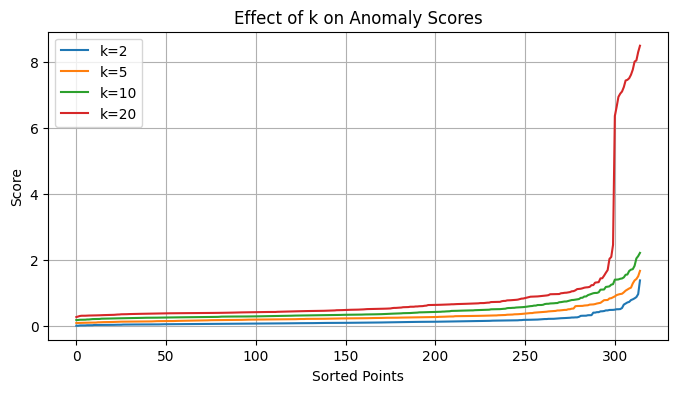

In [ ]:
ks = [2, 5, 10, 20]

plt.figure(figsize=(8, 4))

for k_val in ks:
    scores = knn_anomaly_score(X, k=k_val, method="kth")
    plt.plot(sorted(scores), label=f"k={k_val}")

plt.title("Effect of k on Anomaly Scores")
plt.xlabel("Sorted Points")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

## **Code Block 3.4: Generate synthetic ECG signal using Gaussian waves**

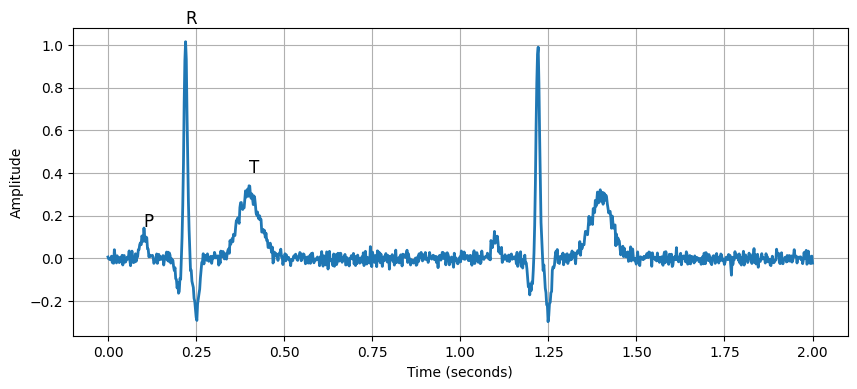

In [ ]:
def generate_ecg(t, heart_rate=60):
    ecg = np.zeros_like(t)
    period = 60 / heart_rate

    for beat_start in np.arange(0, t[-1], period):
        # P wave
        ecg += 0.1 * np.exp(-((t - (beat_start + 0.1))**2) / (2 * 0.01**2))
        # Q wave
        ecg += -0.15 * np.exp(-((t - (beat_start + 0.2))**2) / (2 * 0.008**2))
        # R wave (sharp spike)
        ecg += 1.0 * np.exp(-((t - (beat_start + 0.22))**2) / (2 * 0.005**2))
        # S wave
        ecg += -0.25 * np.exp(-((t - (beat_start + 0.25))**2) / (2 * 0.008**2))
        # T wave
        ecg += 0.3 * np.exp(-((t - (beat_start + 0.4))**2) / (2 * 0.03**2))

    return ecg

fs = 500
duration = 2  # seconds (≈2 heartbeats at 60 bpm)
t = np.linspace(0, duration, fs * duration)
ecg = generate_ecg(t)
# small noise
ecg += 0.02 * np.random.randn(len(t))

plt.figure(figsize=(10,4))
plt.plot(t, ecg, linewidth=2)
plt.title("Sample ECG Signal (Two Heartbeats)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()

plt.text(0.1, 0.15, 'P', fontsize=12)
plt.text(0.22, 1.1, 'R', fontsize=12)
plt.text(0.4, 0.4, 'T', fontsize=12)

plt.show()

## **Code Block 3.5: Leveraging repetition → Windowing + Clustering (model of normal)**


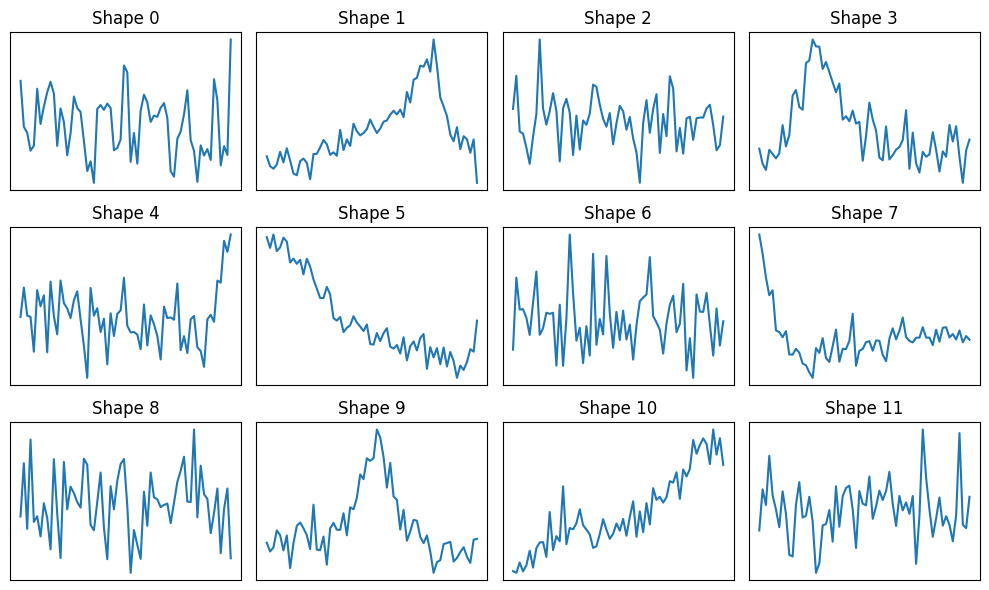

In [ ]:
def make_windows(x, window_size=64, stride=16):
    W, pos = [], []
    for i in range(0, len(x) - window_size + 1, stride):
        W.append(x[i:i+window_size])
        pos.append(i)
    return np.array(W), np.array(pos)

# normalize per-window (helps clustering)
def normalize_windows(W):
    mu = W.mean(axis=1, keepdims=True)
    sd = W.std(axis=1, keepdims=True) + 1e-8
    return (W - mu) / sd

W, pos = make_windows(ecg, window_size=64, stride=16)
Wn = normalize_windows(W)

k = 12
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
kmeans.fit(Wn)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 6))
rows, cols = 3, 4
for i in range(min(k, rows*cols)):
    plt.subplot(rows, cols, i+1)
    plt.plot(centroids[i])
    plt.title(f"Shape {i}")
    plt.xticks([]); plt.yticks([])
plt.suptitle("Dictionary of Typical ECG Window Shapes (Model of Normal)")
plt.tight_layout()
plt.show()

## **Code Block 3.6: Original, Reconstructed and Reconstruction error of ECG signal)**

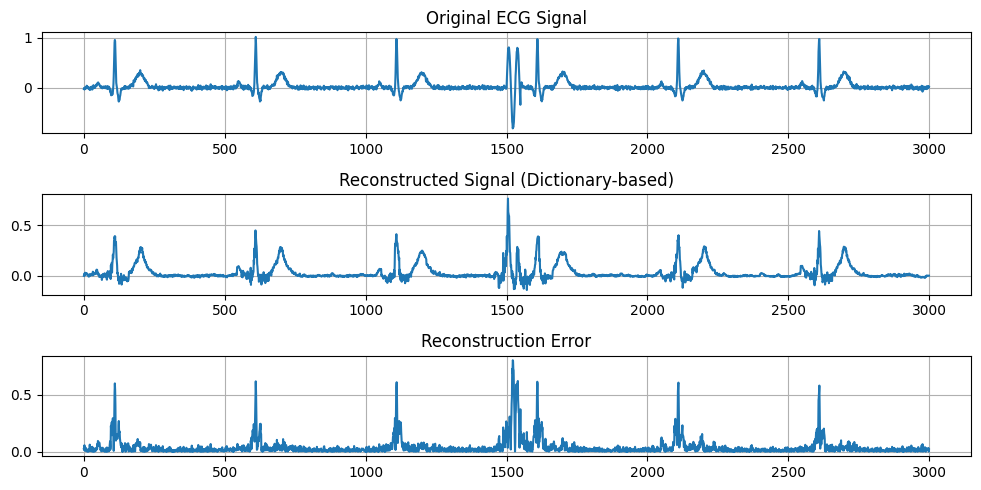

In [ ]:
def generate_ecg(t, heart_rate=60):
    ecg = np.zeros_like(t)
    period = 60 / heart_rate

    for beat_start in np.arange(0, t[-1], period):
        ecg += 0.1 * np.exp(-((t - (beat_start + 0.1))**2) / (2 * 0.01**2))   # P
        ecg += -0.15 * np.exp(-((t - (beat_start + 0.2))**2) / (2 * 0.008**2)) # Q
        ecg += 1.0 * np.exp(-((t - (beat_start + 0.22))**2) / (2 * 0.005**2))  # R
        ecg += -0.25 * np.exp(-((t - (beat_start + 0.25))**2) / (2 * 0.008**2))# S
        ecg += 0.3 * np.exp(-((t - (beat_start + 0.4))**2) / (2 * 0.03**2))    # T

    return ecg

# Time axis
fs = 500
t = np.linspace(0, 6, 6*fs)

# Normal training signal
train_ecg = generate_ecg(t[:2000]) + 0.02*np.random.randn(2000)

# Test signal with anomaly
test_ecg = generate_ecg(t) + 0.02*np.random.randn(len(t))
test_ecg[1500:1550] += 0.8 * np.sin(np.linspace(0, 10, 50))

# Windowing
def window_signal(signal, window_size=64, stride=16):
    windows = []
    positions = []
    for i in range(0, len(signal) - window_size, stride):
        windows.append(signal[i:i+window_size])
        positions.append(i)
    return np.array(windows), np.array(positions)

W_train, _ = window_signal(train_ecg)
W_test, pos = window_signal(test_ecg)

# Normalize
mean = W_train.mean(axis=1, keepdims=True)
std = W_train.std(axis=1, keepdims=True) + 1e-8
W_train_norm = (W_train - mean) / std

# Learn dictionary (k-means)
kmeans = KMeans(n_clusters=15, random_state=42)
kmeans.fit(W_train_norm)


# Reconstruction
def reconstruct_signal(W, pos, model):
    W_norm = (W - W.mean(axis=1, keepdims=True)) / (W.std(axis=1, keepdims=True) + 1e-8)
    labels = model.predict(W_norm)
    centroids = model.cluster_centers_[labels]

    # de-normalize
    W_rec = centroids * W.std(axis=1, keepdims=True) + W.mean(axis=1, keepdims=True)

    # overlap-add reconstruction
    recon = np.zeros_like(test_ecg)
    counts = np.zeros_like(test_ecg)

    for i, start in enumerate(pos):
        recon[start:start+64] += W_rec[i]
        counts[start:start+64] += 1

    counts[counts == 0] = 1
    return recon / counts

reconstructed = reconstruct_signal(W_test, pos, kmeans)

# Reconstruction error
error = np.abs(test_ecg - reconstructed)

plt.figure(figsize=(10,5))

# Original
plt.subplot(3,1,1)
plt.plot(test_ecg)
plt.title("Original ECG Signal")
plt.grid()

# Reconstructed
plt.subplot(3,1,2)
plt.plot(reconstructed)
plt.title("Reconstructed Signal (Dictionary-based)")
plt.grid()

# Error
plt.subplot(3,1,3)
plt.plot(error)
plt.title("Reconstruction Error")
plt.grid()

plt.tight_layout()
plt.show()